# 04 · CNN–LSTM for rainfall over Ireland

Each example uses six hourly cloud maps and temperature and humidity at five stations. The target is rainfall at the **following hour**. We first keep the rainfall-amount experiment, then train a separate model for four rainfall categories. Run the cells from top to bottom in VS Code. The original 70/15/15 chronological split comes from `training_sequences.npz`.

## 1 · Check the Python environment

Print the Python executable to confirm that VS Code is using your intended environment.

In [1]:
import sys
print(sys.executable)

c:\Users\engma\anaconda3\envs\py310env\python.exe


## 3 · Locate prepared data

Check that the saved examples, chronological split, and cloud file are available. Each example has a sequence of six images and a rainfall target at five stations.

In [2]:
from pathlib import Path
import numpy as np

prepared_file = Path("data/processed/training_sequences.npz")
cloud_file = Path(
    "data/raw/satellite/ireland_clouds_20240101_20250101.npz"
)

with np.load(prepared_file) as prepared:
    print("Saved arrays:", prepared.files)
    print("Image positions:", prepared["image_positions"].shape)
    print("Weather inputs:", prepared["weather"].shape)
    print("Rainfall targets:", prepared["rain"].shape)
    print("Training examples:", len(prepared["train_rows"]))
    print("Validation examples:", len(prepared["validation_rows"]))
    print("Test examples:", len(prepared["test_rows"]))

print("Cloud file found:", cloud_file.exists())

Saved arrays: ['image_positions', 'weather', 'rain', 'train_rows', 'validation_rows', 'test_rows', 'weather_mean', 'weather_std', 'station_names']
Image positions: (8778, 6)
Weather inputs: (8778, 6, 10)
Rainfall targets: (8778, 5)
Training examples: 6136
Validation examples: 1315
Test examples: 1315
Cloud file found: True


## 4 · Load the prepared arrays

Load the example positions, weather measurements, rainfall targets, and split rows. The cloud masks remain indexed by their original hourly positions.

In [3]:
with np.load(prepared_file) as prepared:
    image_positions = prepared["image_positions"]
    weather = prepared["weather"]
    rain = prepared["rain"]

    train_rows = prepared["train_rows"]
    validation_rows = prepared["validation_rows"]
    test_rows = prepared["test_rows"]

with np.load(cloud_file) as clouds:
    cloud_masks = clouds["cloud_mask"]

print("Hourly cloud masks:", cloud_masks.shape)
print("One training example uses images:", image_positions[train_rows[0]])

Hourly cloud masks: (8784, 90, 120)
One training example uses images: [0 1 2 3 4 5]


## 5 · Create the rainfall dataset

For one example, turn six categorical cloud masks into two CNN channels: cloud present and valid observation. The rainfall target contains five amounts in mm.

In [4]:
import torch
from torch.utils.data import Dataset

class RainfallDataset(Dataset):
    def __init__(self, rows):
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows[index]

        # Six cloud masks, reduced from 90×120 to 45×60
        masks = cloud_masks[image_positions[row], ::2, ::2]

        cloud = (masks == 2).astype(np.float32)
        valid = (masks != 3).astype(np.float32)

        # PyTorch CNN expects channels before height and width:
        # (6 hours, 2 channels, 45 rows, 60 columns)
        images = np.stack([cloud, valid], axis=1)

        station_inputs = weather[row]  # (6 hours, 10 values)
        rainfall = rain[row]           # (5 stations)

        return (
            torch.from_numpy(images),
            torch.from_numpy(station_inputs),
            torch.from_numpy(rainfall),
        )

train_dataset = RainfallDataset(train_rows)

example_images, example_weather, example_rain = train_dataset[0]

print("Images:", example_images.shape)
print("Station inputs:", example_weather.shape)
print("Rainfall target:", example_rain.shape)

Images: torch.Size([6, 2, 45, 60])
Station inputs: torch.Size([6, 10])
Rainfall target: torch.Size([5])


## 6 · Make rainfall batches

Shuffle only the training batches. Keep validation and test in their existing time order; the split itself remains chronological.

In [5]:
from torch.utils.data import DataLoader

validation_dataset = RainfallDataset(validation_rows)
test_dataset = RainfallDataset(test_rows)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

batch_images, batch_weather, batch_rain = next(iter(train_loader))

print("Batch images:", batch_images.shape)
print("Batch station inputs:", batch_weather.shape)
print("Batch rainfall targets:", batch_rain.shape)

Batch images: torch.Size([16, 6, 2, 45, 60])
Batch station inputs: torch.Size([16, 6, 10])
Batch rainfall targets: torch.Size([16, 5])


## 7 · Build the rainfall-amount CNN–LSTM

The CNN learns a feature vector from each map; the LSTM reads those features alongside station measurements across six hours. The last layer produces one non-negative amount for each station.

In [6]:
import torch.nn as nn

class CloudRainModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Turn one cloud map into 32 learned features
        self.cnn = nn.Sequential(
            nn.Conv2d(2, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(16 * 4 * 4, 32),
            nn.ReLU()
        )

        # Each hour has 32 image features + 10 station measurements
        self.lstm = nn.LSTM(
            input_size=32 + 10,
            hidden_size=32,
            batch_first=True
        )

        # Predict rainfall at five stations
        self.output = nn.Linear(32, 5)
        self.non_negative = nn.Softplus()

    def forward(self, images, station_inputs):
        batch_size, hours, channels, height, width = images.shape

        # Process all images with the same CNN
        images = images.reshape(batch_size * hours, channels, height, width)
        image_features = self.cnn(images)
        image_features = image_features.reshape(batch_size, hours, 32)

        # Join image features and measurements at each hour
        hourly_features = torch.cat(
            [image_features, station_inputs],
            dim=2
        )

        sequence_output, _ = self.lstm(hourly_features)

        # Use the final hour to predict the following hour
        last_hour = sequence_output[:, -1, :]
        rainfall = self.non_negative(self.output(last_hour))

        return rainfall

model = CloudRainModel()

# Check that one batch passes through the model
with torch.no_grad():
    predictions = model(batch_images, batch_weather)

print("Predictions:", predictions.shape)
print("Targets:", batch_rain.shape)

Predictions: torch.Size([16, 5])
Targets: torch.Size([16, 5])


## 8 · Try one training update

This cell updates the rainfall-amount model **once** to check that forward prediction, loss calculation, and backpropagation all work. The following training loop continues from this updated model.

In [7]:
loss_function = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model.train()

# 1. Clear gradients from any previous update
optimizer.zero_grad()

# 2. Predict rainfall for this batch
predictions = model(batch_images, batch_weather)

# 3. Measure the difference from recorded rainfall
loss = loss_function(predictions, batch_rain)

# 4. Calculate gradients and update the model
loss.backward()
optimizer.step()

print("Loss after one training batch:", loss.item())

Loss after one training batch: 0.2627936005592346


## 9 · Train and save the best amount model

Print the training and validation Smooth L1 loss every epoch. Save the weights when validation loss reaches a new minimum.

In [8]:
from pathlib import Path

epochs = 10
best_validation_loss = float("inf")
history = []

models_folder = Path("models")
models_folder.mkdir(exist_ok=True)
model_file = models_folder / "best_cloud_rain_model.pt"

for epoch in range(1, epochs + 1):
    # Training
    model.train()
    training_loss_total = 0

    for images, station_inputs, targets in train_loader:
        optimizer.zero_grad()

        predictions = model(images, station_inputs)
        loss = loss_function(predictions, targets)

        loss.backward()
        optimizer.step()

        training_loss_total += loss.item() * len(targets)

    training_loss = training_loss_total / len(train_dataset)

    # Validation
    model.eval()
    validation_loss_total = 0

    with torch.no_grad():
        for images, station_inputs, targets in validation_loader:
            predictions = model(images, station_inputs)
            loss = loss_function(predictions, targets)

            validation_loss_total += loss.item() * len(targets)

    validation_loss = validation_loss_total / len(validation_dataset)

    history.append((training_loss, validation_loss))

    print(
        f"Epoch {epoch}/{epochs} | "
        f"Training loss: {training_loss:.4f} | "
        f"Validation loss: {validation_loss:.4f}",
        flush=True
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        torch.save(model.state_dict(), model_file)
        print(f"  Saved best model to {model_file}", flush=True)

Epoch 1/10 | Training loss: 0.0668 | Validation loss: 0.0604
  Saved best model to models\best_cloud_rain_model.pt
Epoch 2/10 | Training loss: 0.0564 | Validation loss: 0.0597
  Saved best model to models\best_cloud_rain_model.pt
Epoch 3/10 | Training loss: 0.0553 | Validation loss: 0.0593
  Saved best model to models\best_cloud_rain_model.pt
Epoch 4/10 | Training loss: 0.0541 | Validation loss: 0.0581
  Saved best model to models\best_cloud_rain_model.pt
Epoch 5/10 | Training loss: 0.0534 | Validation loss: 0.0583
Epoch 6/10 | Training loss: 0.0531 | Validation loss: 0.0580
  Saved best model to models\best_cloud_rain_model.pt
Epoch 7/10 | Training loss: 0.0529 | Validation loss: 0.0578
  Saved best model to models\best_cloud_rain_model.pt
Epoch 8/10 | Training loss: 0.0509 | Validation loss: 0.0589
Epoch 9/10 | Training loss: 0.0500 | Validation loss: 0.0575
  Saved best model to models\best_cloud_rain_model.pt
Epoch 10/10 | Training loss: 0.0487 | Validation loss: 0.0568
  Saved bes

## 10 · Continue amount training with early stopping

Continue up to the maximum number of epochs and stop after several epochs without validation improvement. Preserve the best saved weights.

In [13]:
max_epochs = 30
patience = 5

# Keep the best result from the initial epochs
best_validation_loss = min(val_loss for _, val_loss in history)
epochs_without_improvement = 0
next_epoch = len(history) + 1

for epoch in range(next_epoch, max_epochs + 1):
    model.train()
    training_loss_total = 0

    for images, station_inputs, targets in train_loader:
        optimizer.zero_grad()

        predictions = model(images, station_inputs)
        loss = loss_function(predictions, targets)

        loss.backward()
        optimizer.step()

        training_loss_total += loss.item() * len(targets)

    training_loss = training_loss_total / len(train_dataset)

    model.eval()
    validation_loss_total = 0

    with torch.no_grad():
        for images, station_inputs, targets in validation_loader:
            predictions = model(images, station_inputs)
            loss = loss_function(predictions, targets)

            validation_loss_total += loss.item() * len(targets)

    validation_loss = validation_loss_total / len(validation_dataset)
    history.append((training_loss, validation_loss))

    print(
        f"Epoch {epoch}/{max_epochs} | "
        f"Training loss: {training_loss:.4f} | "
        f"Validation loss: {validation_loss:.4f}",
        flush=True
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_file)
        print("  New best model saved.", flush=True)
    else:
        epochs_without_improvement += 1
        print(
            f"  No improvement: {epochs_without_improvement}/{patience}",
            flush=True
        )

    if epochs_without_improvement >= patience:
        print("Stopped early: validation loss did not improve.")
        break

print(f"Best validation loss: {best_validation_loss:.4f}")
print("Saved model:", model_file)

Epoch 11/30 | Training loss: 0.0439 | Validation loss: 0.0562
  No improvement: 1/5
Epoch 12/30 | Training loss: 0.0433 | Validation loss: 0.0572
  No improvement: 2/5
Epoch 13/30 | Training loss: 0.0427 | Validation loss: 0.0570
  No improvement: 3/5
Epoch 14/30 | Training loss: 0.0419 | Validation loss: 0.0567
  No improvement: 4/5
Epoch 15/30 | Training loss: 0.0416 | Validation loss: 0.0570
  No improvement: 5/5
Stopped early: validation loss did not improve.
Best validation loss: 0.0556
Saved model: models\best_cloud_rain_model.pt


## 11 · Plot amount-model learning

Compare training and validation loss. A widening gap can indicate that training improvements are not carrying over to validation.

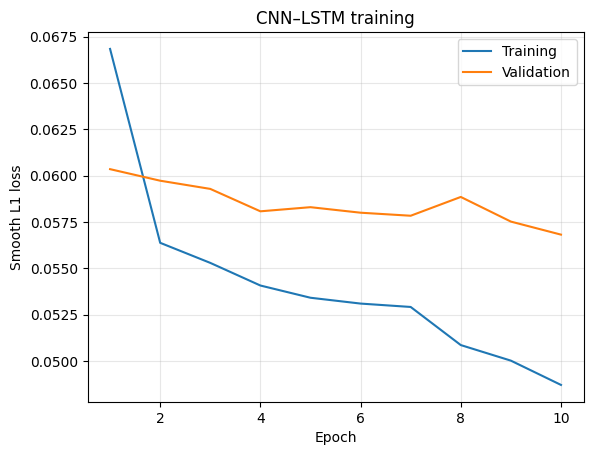

In [12]:
import matplotlib.pyplot as plt

training_losses = [train_loss for train_loss, _ in history]
validation_losses = [val_loss for _, val_loss in history]
epoch_numbers = range(1, len(history) + 1)

plt.plot(epoch_numbers, training_losses, label="Training")
plt.plot(epoch_numbers, validation_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Smooth L1 loss")
plt.title("CNN–LSTM training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 12 · Evaluate the amount model on the held-out test set

Reload the checkpoint chosen on validation data. Compare its Smooth L1 loss with a model that always predicts zero rainfall.

In [13]:
# Load the weights from the best validation epoch
best_model = CloudRainModel()
best_model.load_state_dict(
    torch.load(model_file, map_location="cpu", weights_only=True)
)
best_model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for images, station_inputs, targets in test_loader:
        predictions = best_model(images, station_inputs)
        all_predictions.append(predictions)
        all_targets.append(targets)

test_predictions = torch.cat(all_predictions)
test_targets = torch.cat(all_targets)

model_loss = loss_function(test_predictions, test_targets).item()
dry_baseline = torch.zeros_like(test_targets)
baseline_loss = loss_function(dry_baseline, test_targets).item()

print(f"Model test loss:         {model_loss:.4f}")
print(f"Always-zero test loss:   {baseline_loss:.4f}")

Model test loss:         0.0599
Always-zero test loss:   0.0728


## 13 · Check errors in rainfall units

MAE and RMSE are in mm. Report MAE for all station-hours and separately for hours with recorded rain.

In [14]:
errors = test_predictions - test_targets
rainy = test_targets > 0

mae = errors.abs().mean()
rmse = torch.sqrt((errors ** 2).mean())
rainy_mae = errors[rainy].abs().mean()

baseline_mae = test_targets.abs().mean()
baseline_rainy_mae = test_targets[rainy].abs().mean()

print(f"Rainy station-hours: {rainy.sum().item()} of {rainy.numel()}")
print(f"Model MAE:             {mae.item():.3f} mm")
print(f"Always-zero MAE:       {baseline_mae.item():.3f} mm")
print(f"Model RMSE:            {rmse.item():.3f} mm")
print(f"Model MAE when rainy:  {rainy_mae.item():.3f} mm")
print(f"Zero MAE when rainy:   {baseline_rainy_mae.item():.3f} mm")

Rainy station-hours: 1409 of 6575
Model MAE:             0.158 mm
Always-zero MAE:       0.129 mm
Model RMSE:            0.474 mm
Model MAE when rainy:  0.468 mm
Zero MAE when rainy:   0.604 mm


## 14 · Check each station

Read the station names and print overall and rainy-hour MAE. A single average can hide differences between stations.

In [15]:
with np.load(prepared_file) as prepared:
    station_names = prepared["station_names"]

for station_index, name in enumerate(station_names):
    actual = test_targets[:, station_index]
    predicted = test_predictions[:, station_index]
    rainy_hours = actual > 0

    station_mae = (predicted - actual).abs().mean()
    rainy_mae = (predicted[rainy_hours] - actual[rainy_hours]).abs().mean()

    print(
        f"{name}: MAE {station_mae.item():.3f} mm | "
        f"rainy-hour MAE {rainy_mae.item():.3f} mm | "
        f"rainy hours {rainy_hours.sum().item()}"
    )

Casement: MAE 0.109 mm | rainy-hour MAE 0.462 mm | rainy hours 178
Cork: MAE 0.186 mm | rainy-hour MAE 0.446 mm | rainy hours 364
Shannon: MAE 0.170 mm | rainy-hour MAE 0.469 mm | rainy hours 307
Knock: MAE 0.224 mm | rainy-hour MAE 0.480 mm | rainy hours 405
Dublin: MAE 0.101 mm | rainy-hour MAE 0.497 mm | rainy hours 155


## 15 · Plot a difficult rainy period

Show recorded and predicted hourly rain near the largest Knock rainfall hour in the test period.

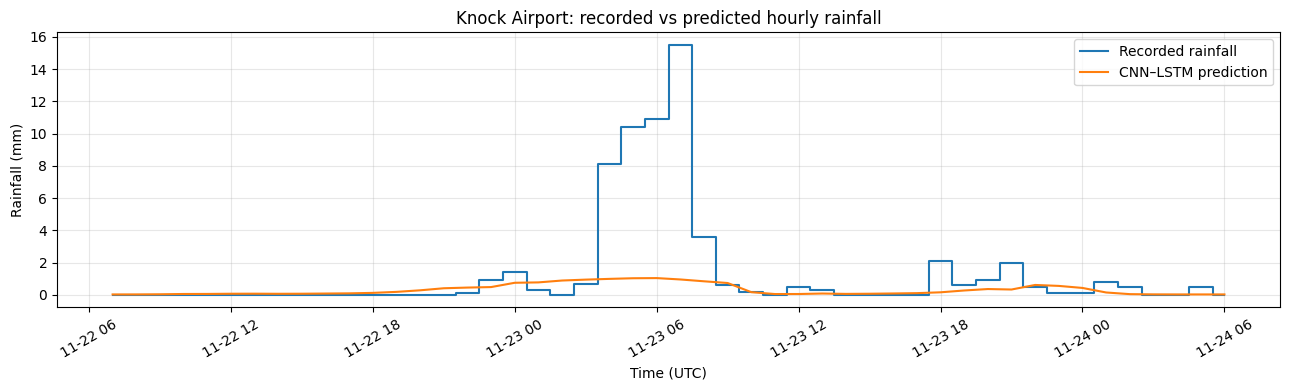

In [16]:
station_index = 3  # Knock: Casement=0, Cork=1, Shannon=2, Knock=3, Dublin=4

observed = test_targets[:, station_index].numpy()
predicted = test_predictions[:, station_index].numpy()

# Find the largest recorded rainfall hour, then show nearby hours
peak_hour = np.argmax(observed)
start = max(0, peak_hour - 24)
end = min(len(observed), start + 48)

# Recover the timestamps for the test targets
with np.load(cloud_file) as cloud_data:
    all_times = cloud_data["times"]

test_times = all_times[test_rows + 6]

plt.figure(figsize=(13, 4))
plt.step(
    test_times[start:end],
    observed[start:end],
    where="mid",
    label="Recorded rainfall"
)
plt.plot(
    test_times[start:end],
    predicted[start:end],
    label="CNN–LSTM prediction"
)

plt.title("Knock Airport: recorded vs predicted hourly rainfall")
plt.ylabel("Rainfall (mm)")
plt.xlabel("Time (UTC)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 16 · Inspect larger rainfall errors

Report how often recorded rainfall reached at least 2 mm in an hour and how much the amount model predicted for those hours.

In [17]:
heavy_rain = test_targets >= 2.0

print("Station-hours with at least 2 mm rain:", heavy_rain.sum().item())

print(
    "Average recorded amount:",
    f"{test_targets[heavy_rain].mean().item():.2f} mm"
)
print(
    "Average predicted amount:",
    f"{test_predictions[heavy_rain].mean().item():.2f} mm"
)
print(
    "MAE during these hours:",
    f"{(test_predictions[heavy_rain] - test_targets[heavy_rain]).abs().mean().item():.2f} mm"
)

Station-hours with at least 2 mm rain: 94
Average recorded amount: 3.26 mm
Average predicted amount: 0.44 mm
MAE during these hours: 2.82 mm


## 17 · Count higher-rainfall cases in each split

Count station-hours with rainfall of at least 2 mm. These cases are uncommon in all three splits.

In [18]:
for name, rows in [
    ("Training", train_rows),
    ("Validation", validation_rows),
    ("Test", test_rows),
]:
    amounts = rain[rows]  # Five station rainfall values per example
    heavy = amounts >= 2.0

    print(
        f"{name}: {heavy.sum()} heavy-rain station-hours "
        f"out of {amounts.size} "
        f"({100 * heavy.mean():.2f}%)"
    )

Training: 364 heavy-rain station-hours out of 30680 (1.19%)
Validation: 86 heavy-rain station-hours out of 6575 (1.31%)
Test: 94 heavy-rain station-hours out of 6575 (1.43%)


## 18 · Count rainy hours in each split

A dry prediction is often correct. Compare rainy-hour frequency across splits before judging any classifier by overall accuracy.

In [19]:
# How often does it rain at the five stations?
for name, rows in [
    ("Training", train_rows),
    ("Validation", validation_rows),
    ("Test", test_rows),
]:
    station_hours = rain[rows]
    rainy_hours = (station_hours > 0).sum()
    total_hours = station_hours.size

    print(
        f"{name}: {rainy_hours} rainy station-hours "
        f"out of {total_hours} "
        f"({100 * rainy_hours / total_hours:.1f}%)"
    )

Training: 5568 rainy station-hours out of 30680 (18.1%)
Validation: 1022 rainy station-hours out of 6575 (15.5%)
Test: 1409 rainy station-hours out of 6575 (21.4%)


## 19 · Explore a rain/no-rain target

Convert positive rainfall to 1 and dry hours to 0. This is a separate possible task; the four-category experiment below uses the original amounts.

In [20]:
# 1 means rain was recorded; 0 means no rain was recorded.
rain_labels = (rain > 0).astype(np.float32)

print("Rainfall amounts shape:", rain.shape)
print("Rain/no-rain labels shape:", rain_labels.shape)
print("First hour, five stations:", rain_labels[0])

Rainfall amounts shape: (8778, 5)
Rain/no-rain labels shape: (8778, 5)
First hour, five stations: [0. 0. 0. 1. 0.]


## 20 · Wrap the data for the binary experiment

Keep the same image and weather input, but return five rain/no-rain targets for each example. The original rainfall dataset remains available.

In [21]:
from torch.utils.data import Dataset

class RainOccurrenceDataset(Dataset):
    def __init__(self, rainfall_dataset):
        self.rainfall_dataset = rainfall_dataset

    def __len__(self):
        return len(self.rainfall_dataset)

    def __getitem__(self, index):
        images, station_inputs, rainfall = self.rainfall_dataset[index]

        # Convert rainfall in mm to five rain/no-rain labels.
        rain_labels = (rainfall > 0).float()

        return images, station_inputs, rain_labels


rain_train_dataset = RainOccurrenceDataset(train_dataset)

images, station_inputs, labels = rain_train_dataset[0]
print("Cloud images:", images.shape)
print("Station inputs:", station_inputs.shape)
print("Rain/no-rain labels:", labels)

Cloud images: torch.Size([6, 2, 45, 60])
Station inputs: torch.Size([6, 10])
Rain/no-rain labels: tensor([0., 0., 0., 1., 0.])


## 21 · Batch the binary examples

Create training and validation loaders for the binary target. These loaders are exploratory; the classification model below uses four categories.

In [22]:
from torch.utils.data import DataLoader

rain_validation_dataset = RainOccurrenceDataset(validation_dataset)

rain_train_loader = DataLoader(
    rain_train_dataset,
    batch_size=16,
    shuffle=True
)

rain_validation_loader = DataLoader(
    rain_validation_dataset,
    batch_size=16,
    shuffle=False
)

batch_images, batch_weather, batch_labels = next(iter(rain_train_loader))

print("Batch images:", batch_images.shape)
print("Batch station inputs:", batch_weather.shape)
print("Batch rain/no-rain labels:", batch_labels.shape)

Batch images: torch.Size([16, 6, 2, 45, 60])
Batch station inputs: torch.Size([16, 6, 10])
Batch rain/no-rain labels: torch.Size([16, 5])


## 22 · Define four amount categories

0 = dry (0 mm); 1 = light (0–<0.5 mm); 2 = moderate (0.5–<2 mm); 3 = higher rainfall (≥2 mm). These are **project thresholds**, not official meteorological warning levels. Drizzle is a precipitation type, and breezy refers to wind, so neither is a rainfall-amount label.

In [23]:
# Rainfall categories for each station-hour
# 0: dry                 0 mm
# 1: light               more than 0, less than 0.5 mm
# 2: moderate            0.5 to less than 2 mm
# 3: higher rainfall     2 mm or more

rain_classes = np.zeros(rain.shape, dtype=np.int64)

rain_classes[(rain > 0) & (rain < 0.5)] = 1
rain_classes[(rain >= 0.5) & (rain < 2)] = 2
rain_classes[rain >= 2] = 3

class_names = ["Dry", "Light", "Moderate", "Higher rainfall"]

for number, name in enumerate(class_names):
    count = (rain_classes[train_rows] == number).sum()
    print(f"{name}: {count} training station-hours")

Dry: 25112 training station-hours
Light: 3369 training station-hours
Moderate: 1835 training station-hours
Higher rainfall: 364 training station-hours


## 23 · Wrap the data for four-category prediction

Convert each of the five rainfall amounts into an integer category. Category targets must have integer (`torch.int64`) type for the loss used below.

In [24]:
class RainIntensityDataset(Dataset):
    def __init__(self, rainfall_dataset):
        self.rainfall_dataset = rainfall_dataset

    def __len__(self):
        return len(self.rainfall_dataset)

    def __getitem__(self, index):
        images, station_inputs, rainfall = self.rainfall_dataset[index]

        categories = torch.zeros_like(rainfall, dtype=torch.long)
        categories[(rainfall > 0) & (rainfall < 0.5)] = 1
        categories[(rainfall >= 0.5) & (rainfall < 2)] = 2
        categories[rainfall >= 2] = 3

        return images, station_inputs, categories


intensity_train_dataset = RainIntensityDataset(train_dataset)

images, station_inputs, categories = intensity_train_dataset[0]
print("Category numbers:", categories)
print("Target shape:", categories.shape)
print("Target type:", categories.dtype)

Category numbers: tensor([0, 0, 0, 1, 0])
Target shape: torch.Size([5])
Target type: torch.int64


## 24 · Batch the four-category examples

Use the same six maps and weather inputs, but each target now has five category numbers. Shuffle training batches only.

In [25]:
intensity_validation_dataset = RainIntensityDataset(validation_dataset)

intensity_train_loader = DataLoader(
    intensity_train_dataset,
    batch_size=16,
    shuffle=True
)

intensity_validation_loader = DataLoader(
    intensity_validation_dataset,
    batch_size=16,
    shuffle=False
)

batch_images, batch_weather, batch_categories = next(
    iter(intensity_train_loader)
)

print("Images:", batch_images.shape)
print("Weather:", batch_weather.shape)
print("Categories:", batch_categories.shape)
print("First example:", batch_categories[0])

Images: torch.Size([16, 6, 2, 45, 60])
Weather: torch.Size([16, 6, 10])
Categories: torch.Size([16, 5])
First example: tensor([0, 0, 0, 0, 0])


## 25 · Define a separate four-category CNN–LSTM

This model has the same image encoder and time-series structure as the amount model. Its final layer produces **5 × 4 scores**: four possible classes for each of five stations. These are raw scores (*logits*); use `softmax` only when displaying probabilities, not inside the training model. The earlier saved amount model stays separate.

In [26]:
class CloudRainCategoryModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(2, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(16 * 4 * 4, 32),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(input_size=32 + 10, hidden_size=32, batch_first=True)
        self.output = nn.Linear(32, 5 * 4)

    def forward(self, images, station_inputs):
        batch_size, hours, channels, height, width = images.shape

        images = images.reshape(batch_size * hours, channels, height, width)
        image_features = self.cnn(images)
        image_features = image_features.reshape(batch_size, hours, 32)

        hourly_features = torch.cat([image_features, station_inputs], dim=2)
        sequence_output, _ = self.lstm(hourly_features)
        last_hour = sequence_output[:, -1, :]

        scores = self.output(last_hour)
        return scores.reshape(batch_size, 5, 4)


torch.manual_seed(42)
category_model = CloudRainCategoryModel()

with torch.no_grad():
    batch_scores = category_model(batch_images, batch_weather)

print("Class scores:", batch_scores.shape)     # (16, 5 stations, 4 categories)
print("Target categories:", batch_categories.shape)

Class scores: torch.Size([16, 5, 4])
Target categories: torch.Size([16, 5])


## 26 · Choose the classification loss

Cross-entropy compares the four raw scores at each station with the recorded category. Dry hours dominate training, so calculate moderate class weights **from training examples only**. The square root keeps the rare category from receiving an extreme weight. These weights are an experiment, not a guarantee that the rare category will be predicted well.

In [27]:
# Count each category across all training station-hours.
counts = torch.bincount(
    torch.from_numpy(rain_classes[train_rows].reshape(-1)),
    minlength=4,
).float()

# Rarer categories receive more weight, using training data only.
class_weights = torch.sqrt(counts.sum() / counts)
class_weights = class_weights / class_weights.mean()

category_loss_function = nn.CrossEntropyLoss(weight=class_weights)
category_optimizer = torch.optim.Adam(category_model.parameters(), lr=0.001)

example_loss = category_loss_function(
    batch_scores.reshape(-1, 4),
    batch_categories.reshape(-1),
)

print("Class counts:", counts.int().tolist())
print("Class weights:", class_weights.tolist())
print("Loss for an untrained batch:", round(example_loss.item(), 4))

Class counts: [25112, 3369, 1835, 364]
Class weights: [0.2542029321193695, 0.6940178871154785, 0.9403795003890991, 2.1113998889923096]
Loss for an untrained batch: 1.3558


## 27 · Train the four-category model

Show training and validation loss every epoch. Save the weights with the lowest validation loss to `models/best_cloud_rain_category_model.pt`; stop early when validation loss does not improve. This does **not** overwrite `best_cloud_rain_model.pt`, which predicts amounts in mm. Run this training cell once for a fresh run.

In [28]:
category_epochs = 15
category_patience = 4
category_best_loss = float("inf")
category_no_improvement = 0
category_history = []

category_model_file = Path("models/best_cloud_rain_category_model.pt")
category_model_file.parent.mkdir(exist_ok=True)

for epoch in range(1, category_epochs + 1):
    category_model.train()
    train_loss_total = 0.0

    for images, station_inputs, targets in intensity_train_loader:
        category_optimizer.zero_grad()
        scores = category_model(images, station_inputs)
        loss = category_loss_function(scores.reshape(-1, 4), targets.reshape(-1))
        loss.backward()
        category_optimizer.step()
        train_loss_total += loss.item() * targets.numel()

    train_loss = train_loss_total / (len(intensity_train_dataset) * 5)

    category_model.eval()
    validation_loss_total = 0.0
    with torch.no_grad():
        for images, station_inputs, targets in intensity_validation_loader:
            scores = category_model(images, station_inputs)
            loss = category_loss_function(scores.reshape(-1, 4), targets.reshape(-1))
            validation_loss_total += loss.item() * targets.numel()

    validation_loss = validation_loss_total / (len(intensity_validation_dataset) * 5)
    category_history.append((train_loss, validation_loss))

    print(
        f"Epoch {epoch}/{category_epochs} | "
        f"Training loss: {train_loss:.4f} | "
        f"Validation loss: {validation_loss:.4f}",
        flush=True,
    )

    if validation_loss < category_best_loss:
        category_best_loss = validation_loss
        category_no_improvement = 0
        torch.save(category_model.state_dict(), category_model_file)
        print("  Saved best category model.", flush=True)
    else:
        category_no_improvement += 1

    if category_no_improvement >= category_patience:
        print("Stopped early: validation loss did not improve.")
        break

print("Saved category model:", category_model_file)

Epoch 1/15 | Training loss: 1.0135 | Validation loss: 0.8179
  Saved best category model.
Epoch 2/15 | Training loss: 0.9237 | Validation loss: 0.7973
  Saved best category model.
Epoch 3/15 | Training loss: 0.8836 | Validation loss: 0.7661
  Saved best category model.
Epoch 4/15 | Training loss: 0.8612 | Validation loss: 0.7740
Epoch 5/15 | Training loss: 0.8458 | Validation loss: 0.7433
  Saved best category model.
Epoch 6/15 | Training loss: 0.8286 | Validation loss: 0.7476
Epoch 7/15 | Training loss: 0.8149 | Validation loss: 0.7545
Epoch 8/15 | Training loss: 0.8047 | Validation loss: 0.7525
Epoch 9/15 | Training loss: 0.7958 | Validation loss: 0.7404
  Saved best category model.
Epoch 10/15 | Training loss: 0.7861 | Validation loss: 0.7587
Epoch 11/15 | Training loss: 0.7734 | Validation loss: 0.7593
Epoch 12/15 | Training loss: 0.7650 | Validation loss: 0.7767
Epoch 13/15 | Training loss: 0.7547 | Validation loss: 0.7661
Stopped early: validation loss did not improve.
Saved cate

## 28 · Plot category-model learning

Compare training and validation **weighted cross-entropy** across epochs. Smaller loss is better, but class-by-class results below are essential because dry hours are so common.

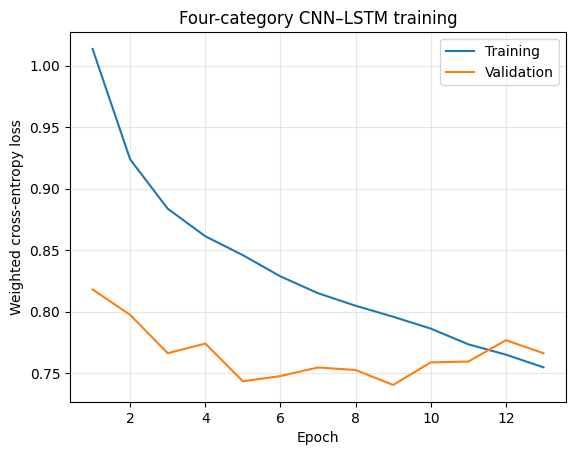

In [29]:
category_train_losses = [pair[0] for pair in category_history]
category_validation_losses = [pair[1] for pair in category_history]

plt.plot(range(1, len(category_history) + 1), category_train_losses, label="Training")
plt.plot(range(1, len(category_history) + 1), category_validation_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Weighted cross-entropy loss")
plt.title("Four-category CNN–LSTM training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 29 · Evaluate the saved classifier once on test data

Load the best checkpoint chosen on validation data. For each station-hour, pick the category with the highest score. Compare with an **always-dry** baseline; accuracy alone can look good even when rainy categories are missed.

In [30]:
intensity_test_dataset = RainIntensityDataset(test_dataset)
intensity_test_loader = DataLoader(
    intensity_test_dataset, batch_size=16, shuffle=False, num_workers=0
)

best_category_model = CloudRainCategoryModel()
best_category_model.load_state_dict(
    torch.load(category_model_file, map_location="cpu", weights_only=True)
)
best_category_model.eval()

predicted_batches = []
recorded_batches = []

with torch.no_grad():
    for images, station_inputs, targets in intensity_test_loader:
        scores = best_category_model(images, station_inputs)
        predicted_batches.append(scores.argmax(dim=-1))
        recorded_batches.append(targets)

predicted_categories = torch.cat(predicted_batches).reshape(-1)
recorded_categories = torch.cat(recorded_batches).reshape(-1)

accuracy = (predicted_categories == recorded_categories).float().mean()
always_dry_accuracy = (recorded_categories == 0).float().mean()

print(f"Category model test accuracy: {accuracy.item():.1%}")
print(f"Always-dry test accuracy:     {always_dry_accuracy.item():.1%}")

Category model test accuracy: 74.8%
Always-dry test accuracy:     78.6%


## 30 · Inspect every rainfall category

The table counts recorded versus predicted categories. **Recall** asks what fraction of actual examples of a category were found; **precision** asks what fraction of predictions for that category were right. These reveal whether the model finds rain even if always-dry accuracy is high.

In [31]:
confusion = torch.zeros((4, 4), dtype=torch.int64)
for actual, predicted in zip(recorded_categories, predicted_categories):
    confusion[actual, predicted] += 1

print("Rows = recorded; columns = predicted (Dry, Light, Moderate, Higher)")
print(confusion)
print()

for number, name in enumerate(class_names):
    correct = confusion[number, number].item()
    recorded_count = confusion[number].sum().item()
    predicted_count = confusion[:, number].sum().item()
    recall = correct / recorded_count if recorded_count else 0.0
    precision = correct / predicted_count if predicted_count else 0.0
    print(
        f"{name:17} | recorded {recorded_count:4d} | "
        f"predicted {predicted_count:4d} | "
        f"recall {recall:.1%} | precision {precision:.1%}"
    )

Rows = recorded; columns = predicted (Dry, Light, Moderate, Higher)
tensor([[4501,  488,  165,   12],
        [ 526,  285,  103,    4],
        [  97,  149,  126,   25],
        [  15,   26,   46,    7]])

Dry               | recorded 5166 | predicted 5139 | recall 87.1% | precision 87.6%
Light             | recorded  918 | predicted  948 | recall 31.0% | precision 30.1%
Moderate          | recorded  397 | predicted  440 | recall 31.7% | precision 28.6%
Higher rainfall   | recorded   94 | predicted   48 | recall 7.4% | precision 14.6%
